In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud


In [3]:
df = pd.read_csv("../Data/phrasebank_cleaned.csv")

In [4]:
df.dtypes

sentiment      str
sentence       str
label        int64
dtype: object

In [5]:
print("Duplicate rows :", df.duplicated().sum())

Duplicate rows : 6


## Univariate Anaylsis 

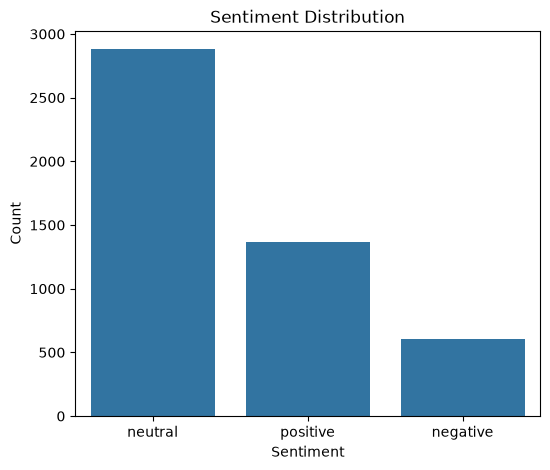

In [6]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='sentiment',
    order=df['sentiment'].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

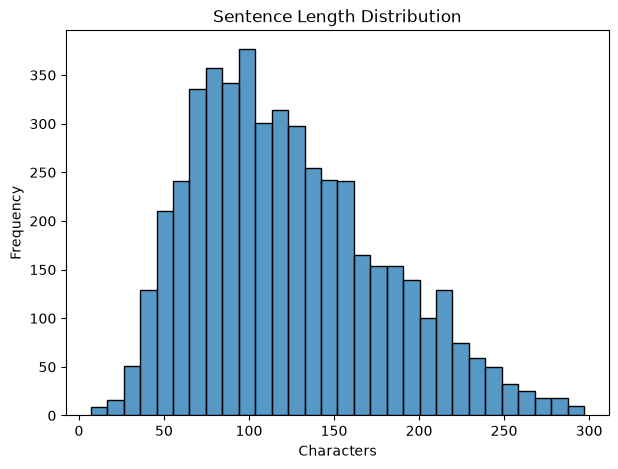

In [7]:
df['sentence_length'] = df['sentence'].str.len()

plt.figure(figsize=(7,5))

sns.histplot(
    df['sentence_length'],
    bins=30
)

plt.title("Sentence Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

In [8]:
df['word_count'] = df['sentence'].str.split().str.len()

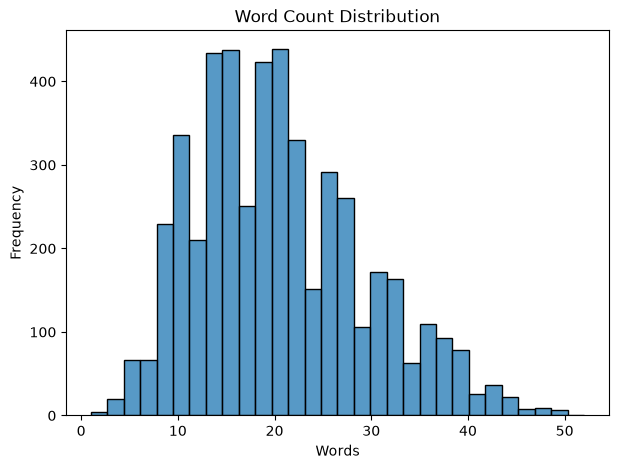

In [9]:
plt.figure(figsize=(7,5))

sns.histplot(
    df['word_count'],
    bins=30
)

plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.show()

In [10]:
df['avg_word_length'] = df['sentence'].apply(
    lambda x: np.mean([len(word) for word in x.split()])
)

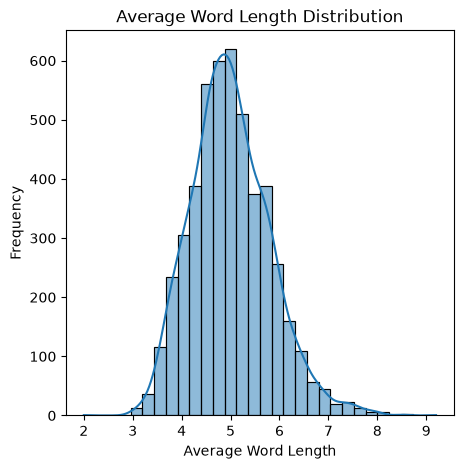

In [11]:
plt.figure(figsize=(5,5))

sns.histplot(
    df['avg_word_length'],
    bins=30,
    kde=True
)

plt.title("Average Word Length Distribution")
plt.xlabel("Average Word Length")
plt.ylabel("Frequency")

plt.show()

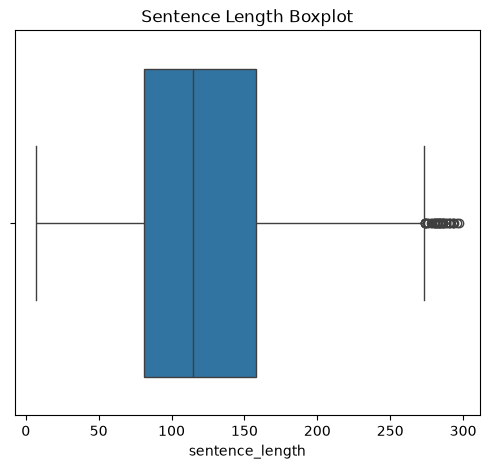

In [12]:
plt.figure(figsize=(6,5))

sns.boxplot(x=df['sentence_length'])

plt.title("Sentence Length Boxplot")

plt.show()

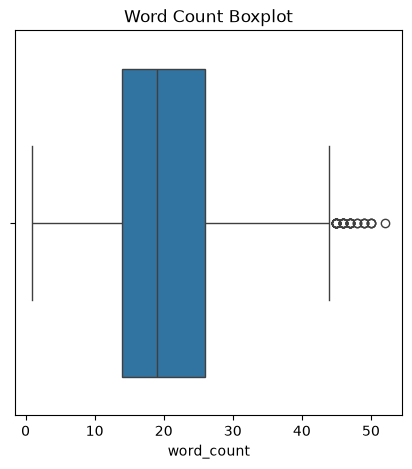

In [13]:
plt.figure(figsize=(5,5))

sns.boxplot(x=df['word_count'])

plt.title("Word Count Boxplot")

plt.show()

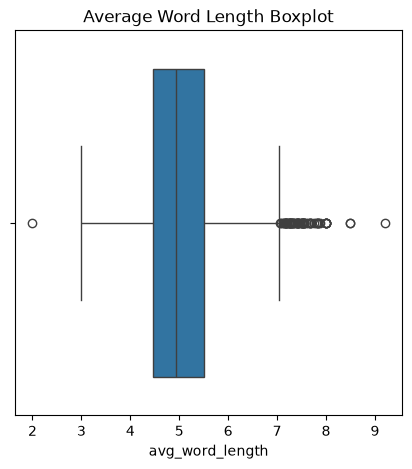

In [14]:
plt.figure(figsize=(5,5))

sns.boxplot(x=df['avg_word_length'])

plt.title("Average Word Length Boxplot")

plt.show()

## Bivariate Analysis 
1. Sentiment vs Sentence
1. Sentiment vs Word Count
1. Sentiment vs Avg Word Length


Text(0, 0.5, 'Sentence Length')

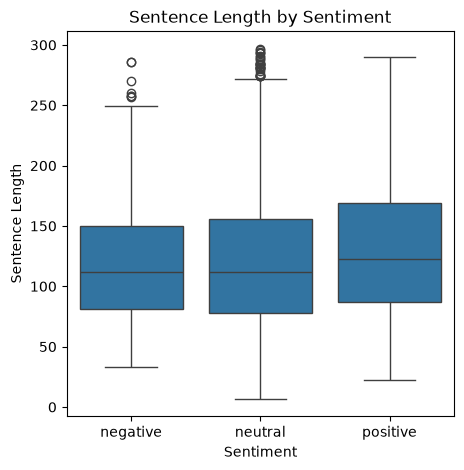

In [15]:
plt.figure(figsize=(5,5))

sns.boxplot(
    data=df,
    x='sentiment',
    y='sentence_length',
    order=['negative','neutral','positive']
)

plt.title("Sentence Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Sentence Length")



Text(0, 0.5, 'Average Word Length')

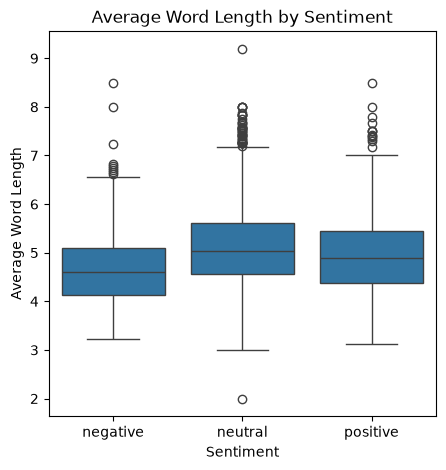

In [16]:
plt.figure(figsize=(5,5))

sns.boxplot(
    data=df,
    x='sentiment',
    y='avg_word_length',
    order=['negative','neutral','positive']
)

plt.title("Average Word Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Length")


Text(0.5, 1.0, 'Sentence Length vs Word Count')

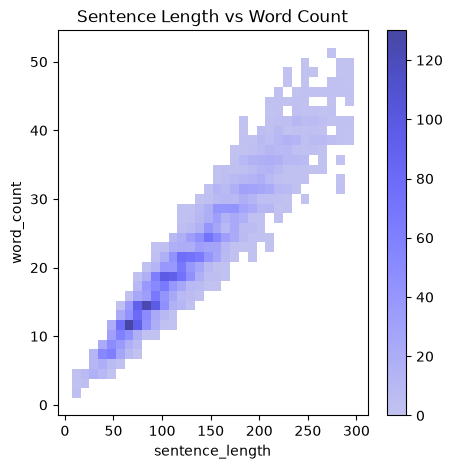

In [17]:
plt.figure(figsize=(5,5))

sns.histplot(
    data=df,
    x='sentence_length',
    y='word_count',
    cbar = True,
    color = 'blue'
    )

plt.title("Sentence Length vs Word Count")


Text(0.5, 1.0, 'Correlation heatmap')

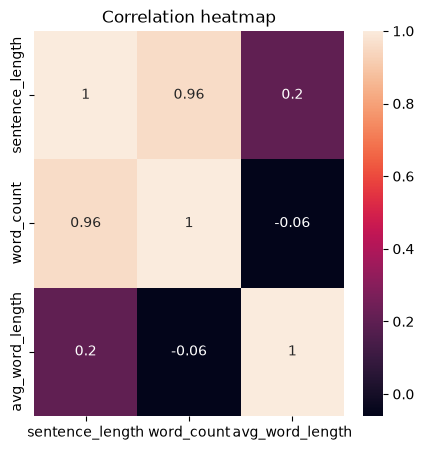

In [18]:
plt.figure(figsize=(5,5))
corr = df[['sentence_length','word_count','avg_word_length']].corr()
sns.heatmap(corr,annot = True)
plt.title("Correlation heatmap")

In [19]:
from collections import Counter

all_words = " ".join(df['sentence']).split()

word_freq = Counter(all_words)

top20 = pd.DataFrame(
    word_freq.most_common(20),
    columns=['Word','Frequency']
)

top20

,Word,Frequency
0,the,6066
1,of,3213
2,in,2969
3,and,2593
4,to,2509
5,a,1723
6,for,1151
7,s,1045
8,eur,1015
9,is,928


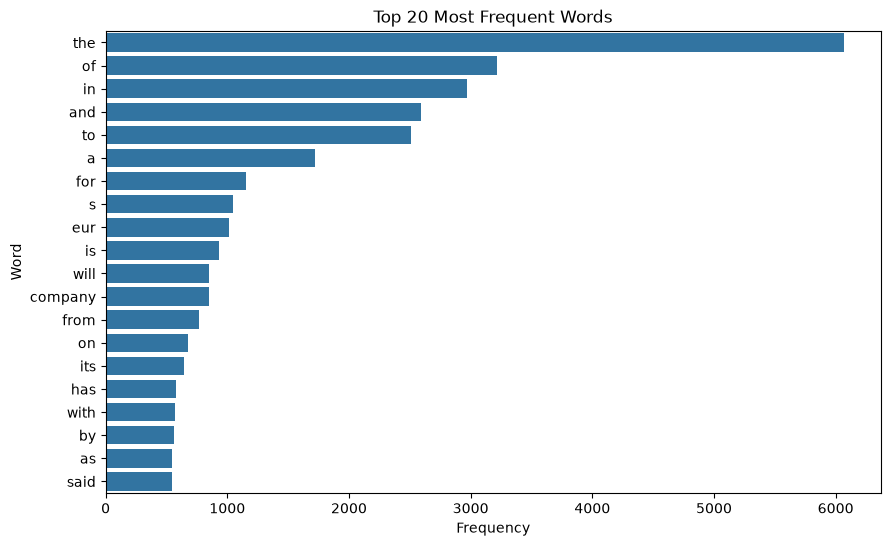

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x='Frequency',
    y='Word'
)

plt.title("Top 20 Most Frequent Words")

plt.show()

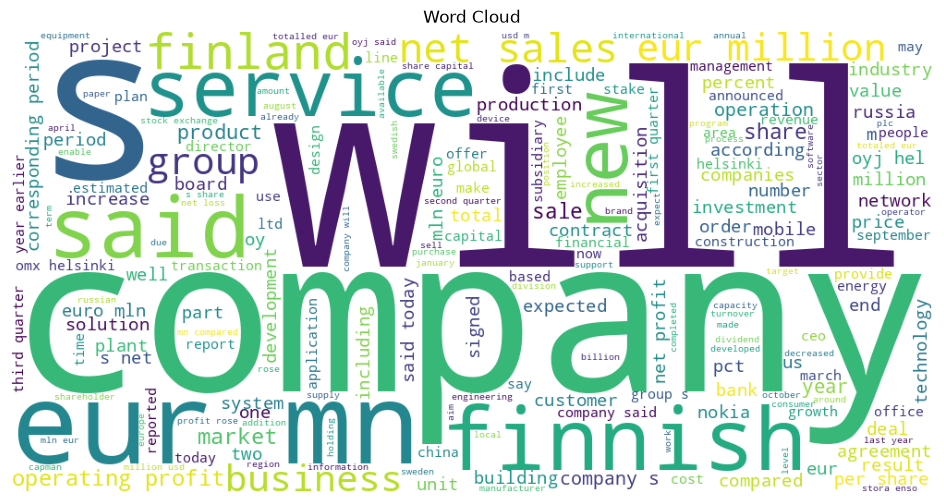

In [21]:

text = " ".join(df['sentence'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

In [22]:
positive = " ".join(
    df[df['sentiment']=="positive"]['sentence']
)

positive_freq = Counter(positive.split()).most_common(15)

pd.DataFrame(
    positive_freq,
    columns=['Word','Frequency']
)

,Word,Frequency
0,the,1587
1,in,969
2,to,918
3,of,851
4,and,679
5,a,525
6,eur,449
7,for,387
8,from,358
9,s,324


In [23]:
neutral = " ".join(
    df[df['sentiment']=="neutral"]['sentence']
)

neutral_freq = Counter(neutral.split()).most_common(15)

pd.DataFrame(
    neutral_freq,
    columns=['Word','Frequency']
)

,Word,Frequency
0,the,3720
1,of,1922
2,and,1717
3,in,1527
4,to,1228
5,a,969
6,is,725
7,for,625
8,s,610
9,will,595


In [24]:
negative = " ".join(
    df[df['sentiment']=="negative"]['sentence']
)

negative_freq = Counter(negative.split()).most_common(15)

pd.DataFrame(
    negative_freq,
    columns=['Word','Frequency']
)

,Word,Frequency
0,the,759
1,in,473
2,of,440
3,to,363
4,eur,325
5,a,229
6,mn,224
7,from,208
8,and,197
9,profit,156


In [25]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english'
)

X = vectorizer.fit_transform(df['sentence'])

bigrams = X.sum(axis=0)

bigram_freq = [
    (word, bigrams[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

bigram_freq = sorted(
    bigram_freq,
    key=lambda x: x[1],
    reverse=True
)

top20 = pd.DataFrame(
    bigram_freq[:20],
    columns=['Bigram','Frequency']
)

top20

,Bigram,Frequency
0,net sales,246
1,operating profit,194
2,mn eur,127
3,corresponding period,108
4,mln euro,107
5,net profit,93
6,oyj hel,85
7,said today,85
8,company said,73
9,omx helsinki,63


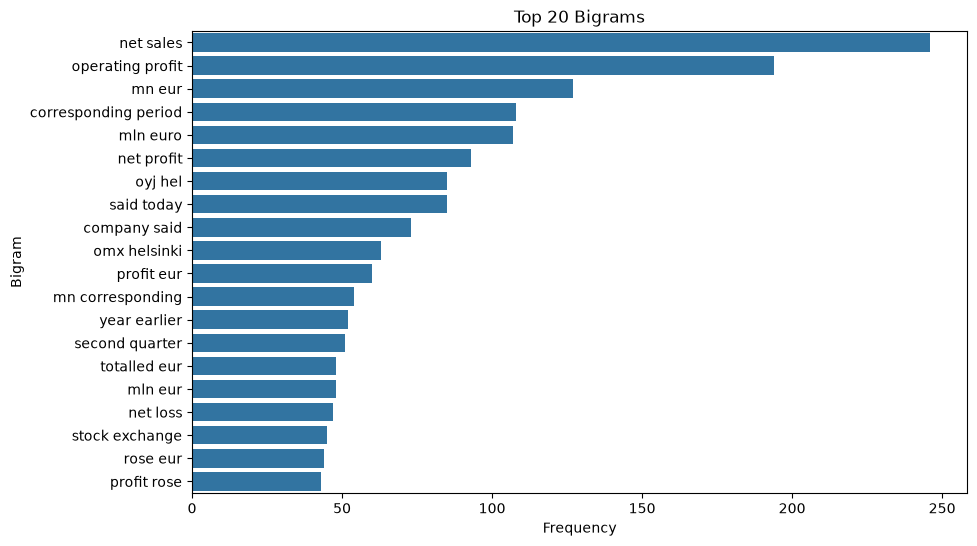

In [26]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top20,
    x='Frequency',
    y='Bigram'
)

plt.title("Top 20 Bigrams")
plt.show()